# 시니어, 누구로 호명되는가
## 뉴스 담론과 서비스 담론의 갭(gap) 분석

**인공지능학과 · 202378167 · 김태연**

분석 기간 2025년 6월 ~ 2026년 6월 · 자료 출처: 빅카인즈 뉴스

---

## 서론

고독사와 독거노인은 오늘날 한국 사회가 마주한 대표적인 위험 신호다. 그와 동시에 스마트홈·실버테크처럼 고령층을 겨냥한 서비스 산업도 빠르게 성장하고 있다. 두 영역은 모두 '시니어'를 이야기하지만, 정작 시니어를 **어떤 존재로 부르는가**는 사뭇 다르다. 뉴스는 고령층을 보호가 필요한 *복지의 수혜 대상*으로 그리는 경향이 있고, 서비스 산업은 같은 고령층을 제품과 서비스를 선택하고 이용하는 *능동적인 소비자*로 바라본다.

이 보고서는 그 **호명(呼名)의 차이**를 주관적 인상이 아니라 측정 가능한 지표로 확인하려는 시도다. 이를 위해 같은 기간에 수집한 두 개의 뉴스 묶음을 비교한다. 하나는 고독사·독거노인을 다룬 담론(코퍼스 A, 20,079건)이고, 다른 하나는 스마트홈·시니어 서비스를 다룬 담론(코퍼스 B, 5,059건)이다.

분석은 다음 네 가지 질문을 따라간다. 첫째, 두 담론은 각각 어떤 주제로 이루어져 있는가. 둘째, 각 담론에서 유독 두드러지는 단어는 무엇인가. 셋째, 시니어를 '수혜의 대상'으로 부르는가 아니면 '능동적 주체'로 부르는가. 넷째, 두 담론이 풍기는 정서는 어떻게 다른가.

공정한 비교를 위해 두 묶음을 같은 기간·같은 방식으로 모았고, 규모가 큰 코퍼스 A를 B와 동일한 크기로 무작위 추출해 1:1로 견주었다. 또한 비율과 출현율처럼 묶음의 크기에 좌우되지 않는 지표만 사용했으며, 전체 코퍼스 A로 다시 계산해 결과가 표본 크기에 흔들리지 않음을 확인했다.

## 분석 준비

분석에 필요한 패키지와 한글 글꼴, 자료 경로, 한국어 감성사전을 준비한다. 아래 네 셀이 실행 환경을 자동으로 갖춘다. (구글 코랩에서는 자료가 담긴 폴더를 드라이브에 올린 뒤 위에서부터 차례대로 실행하면 된다.)

In [1]:
# ① 패키지 설치 (Colab)
!pip install -q konlpy wordcloud gensim networkx openpyxl
# konlpy(Okt)는 JVM 필요. Colab에는 Java가 기본 설치되어 있다.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\compo\anaconda3\python.exe -m pip install --upgrade pip


In [2]:
# ② 한글 폰트 등록 (Colab=나눔고딕 / 로컬=시스템 폰트 자동 탐색)
import os, sys, glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

IN_COLAB = "google.colab" in sys.modules

def _setup_korean_font():
    cands = []
    if IN_COLAB:
        os.system("apt-get -qq install -y fonts-nanum > /dev/null")
        fm._load_fontmanager(try_read_cache=False)
    cands += glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf")
    cands += [r"C:\Windows\Fonts\malgun.ttf"]
    cands += ["/System/Library/Fonts/AppleSDGothicNeo.ttc"]
    cands += glob.glob("/usr/share/fonts/**/Nanum*.ttf", recursive=True)
    for p in cands:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p); name = fm.FontProperties(fname=p).get_name()
            except Exception:
                continue
            plt.rcParams["font.family"] = name; plt.rcParams["axes.unicode_minus"] = False
            return name, p
    return None, None

FONT_NAME, FONT_PATH = _setup_korean_font()
print("폰트:", FONT_NAME, "|", FONT_PATH or "한글폰트 못찾음")

폰트: Malgun Gothic | C:\Windows\Fonts\malgun.ttf


In [ ]:
# ③ 경로 자동 탐색 (하드코딩 없음) — 드라이브 어디에 data/가 있든 찾는다
import glob, os
cands = []
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    cands += ["/content/drive/MyDrive/BDA_FINAL",
              "/content/drive/MyDrive/Colab Notebooks/BDA_FINAL",
              "/content/drive/MyDrive/lonely-death-news-textmining",
              "/content/drive/MyDrive/BDA",
              "/content/drive/MyDrive"]
cands += [".", "..", "../.."]
PROJECT_DIR = next((c for c in cands if glob.glob(f"{c}/data/raw/A/*.xlsx")), None)
# 후보에 없으면 드라이브 전체에서 data/raw/A 를 재귀 탐색
if PROJECT_DIR is None and IN_COLAB:
    hits = glob.glob("/content/drive/MyDrive/**/data/raw/A/*.xlsx", recursive=True)
    if hits:
        d = hits[0]
        for _ in range(4): d = os.path.dirname(d)
        PROJECT_DIR = d
assert PROJECT_DIR, "data/raw/A/*.xlsx 를 찾지 못했습니다. 이 노트북과 함께 data/raw/A, data/raw/B 폴더가 있어야 합니다."
RAW_A = f"{PROJECT_DIR}/data/raw/A"
RAW_B = f"{PROJECT_DIR}/data/raw/B"
files_a = sorted(glob.glob(f"{RAW_A}/*.xlsx"))
files_b = sorted(glob.glob(f"{RAW_B}/*.xlsx"))
print("PROJECT_DIR:", os.path.abspath(PROJECT_DIR))
print("코퍼스 A 엑셀:", [os.path.basename(f) for f in files_a])
print("코퍼스 B 엑셀:", [os.path.basename(f) for f in files_b])
assert files_b, "data/raw/B/*.xlsx (코퍼스 B)를 찾지 못했습니다."


In [ ]:
# ④ KNU 한국어 감성사전 — 묶음에 있으면 그대로 쓰고, 없으면(코랩) 자동 다운로드
import os
bundled = f"{PROJECT_DIR}/data/lexicon/SentiWord_info.json"
if os.path.exists(bundled):
    LEXICON_PATH = bundled
elif IN_COLAB:
    os.system("wget -q -O /content/SentiWord_info.json "
              "https://raw.githubusercontent.com/park1200656/KnuSentiLex/master/data/SentiWord_info.json")
    LEXICON_PATH = "/content/SentiWord_info.json"
else:
    LEXICON_PATH = bundled
print("감성사전:", LEXICON_PATH, "| bytes:", os.path.getsize(LEXICON_PATH))

## 분석에 사용한 함수

본문을 다듬고, 명사를 뽑고, 감성 점수를 매기고, 단어의 변별도와 호명 어휘를 측정하고, 단어 네트워크를 구성하는 함수들을 먼저 정의한다. 불용어는 최소한만 두었다. 흔한 보도 상투어는 걸러내되, 이 분석의 핵심인 '지원·돌봄·서비스·이용' 같은 단어는 호명 방식을 가르는 중요한 단서이므로 그대로 남겼다.

In [5]:
import re, json
from collections import Counter
import numpy as np
import pandas as pd
from konlpy.tag import Okt

okt = Okt()

# 코퍼스 키워드 (복합어 보존용) + 시니어 필터
KEYWORDS_A = ["독거노인", "고독사", "1인 고령가구", "노인 고립", "무연고 사망"]
KEYWORDS_B = ["스마트홈", "실버테크", "고령친화", "돌봄로봇", "스마트경로당", "시니어케어",
              "액티브시니어", "실버산업", "실버타운", "에이지테크", "시니어테크",
              "디지털헬스케어", "노인맞춤돌봄", "비대면돌봄", "안부확인", "반려로봇"]
SENIOR_RE = re.compile("노인|고령|시니어|어르신|독거|실버|경로당|치매|요양")

# 최소 불용어(보도 상투어만) — 내용어는 보존
STOP_WORDS = set(["기자", "뉴스", "사진", "제공", "무단", "전재", "재배포", "금지", "연합뉴스",
    "오전", "오후", "이날", "지난", "올해", "최근", "관련", "통해", "위해", "대한",
    "이번", "당시", "이상", "이후", "이전", "정도", "가운데", "경우", "때문", "기간"])

_URL = re.compile(r"https?://\S+|www\.\S+"); _EMAIL = re.compile(r"\S+@\S+")
_NONKO = re.compile(r"[^가-힣\s]"); _SP = re.compile(r"\s+")
def clean_text(t):
    if not isinstance(t, str): return ""
    t = _URL.sub(" ", t); t = _EMAIL.sub(" ", t); t = _NONKO.sub(" ", t)
    return _SP.sub(" ", t).strip()

_COMP = KEYWORDS_A + KEYWORDS_B
_COMP_PARTS = sorted([(w, tuple(okt.nouns(w))) for w in _COMP], key=lambda x: -len(x[1]))
def _merge_compounds(nouns):
    res, i, n = [], 0, len(nouns)
    while i < n:
        hit = False
        for w, parts in _COMP_PARTS:
            k = len(parts)
            if k >= 2 and tuple(nouns[i:i+k]) == parts:
                res.append(w); i += k; hit = True; break
        if not hit:
            res.append(nouns[i]); i += 1
    return res

def extract_nouns(text, min_len=2):
    c = clean_text(text)
    if not c: return []
    nouns = _merge_compounds(okt.nouns(c))
    return [w for w in nouns if len(w) >= min_len and w not in STOP_WORDS]

_SENTI_POS = {"Noun", "Adjective", "Verb", "Adverb"}
def senti_tokens(text, min_len=2):
    c = clean_text(text)
    if not c: return []
    return [w for w, tag in okt.pos(c, norm=True, stem=True)
            if tag in _SENTI_POS and len(w) >= min_len]

In [6]:
# 감성사전
def load_lexicon(path):
    data = json.load(open(path, encoding="utf-8")); lex = {}
    for x in data:
        w = x["word"]
        if " " in w or not re.fullmatch(r"[가-힣]+", w): continue
        lex[w] = int(x["polarity"])
    return lex

def score_document(text, lexicon):
    score = pos = neg = n = 0
    for w in senti_tokens(text):
        p = lexicon.get(w)
        if p is None: continue
        score += p; n += 1
        if p > 0: pos += 1
        elif p < 0: neg += 1
    label = "positive" if score > 0 else "negative" if score < 0 else "neutral"
    return score, pos, neg, n, label

# log-odds ratio (Monroe et al. 2008, informative Dirichlet prior) — 코퍼스 크기차 보정
def log_odds(counts_a, counts_b, a0=1000.0, min_count=5):
    vocab = [w for w in (set(counts_a) | set(counts_b))
             if counts_a.get(w, 0) + counts_b.get(w, 0) >= min_count]
    bg = {w: counts_a.get(w, 0) + counts_b.get(w, 0) for w in vocab}
    bgtot = sum(bg.values()); na = sum(counts_a.values()); nb = sum(counts_b.values())
    rows = []
    for w in vocab:
        aw = a0 * bg[w] / bgtot
        ya, yb = counts_a.get(w, 0), counts_b.get(w, 0)
        d = (np.log((ya + aw) / (na + a0 - ya - aw)) -
             np.log((yb + aw) / (nb + a0 - yb - aw)))
        v = 1.0/(ya + aw) + 1.0/(yb + aw)
        rows.append((w, d/np.sqrt(v), ya, yb))
    return pd.DataFrame(rows, columns=["word", "z", "freq_A", "freq_B"]).sort_values("z")

# 호명(framing) 어휘 — '수혜·대상화' vs '주체·소비'
RECIPIENT = set(["지원", "보호", "취약", "돌봄", "복지", "수급", "발굴", "대상", "지급", "혜택",
    "사각지대", "저소득", "후원", "기초생활", "수혜", "봉사", "위문", "방문", "도움", "보살핌",
    "구호", "지원금", "생계", "결식", "독거"])
ACTIVE = set(["이용", "구매", "제품", "서비스", "기능", "체험", "사용자", "고객", "소비자", "선택",
    "출시", "판매", "시장", "플랫폼", "기술", "스마트", "편의", "자립", "참여", "수요", "혁신",
    "개발", "산업", "솔루션", "스타트업", "투자", "콘텐츠"])

def framing_index(nouns):
    r = sum(1 for w in nouns if w in RECIPIENT)
    a = sum(1 for w in nouns if w in ACTIVE)
    idx = (a - r) / (a + r) if (a + r) > 0 else np.nan   # -1(수혜) ~ +1(주체)
    return r, a, idx

# 동시출현 네트워크
from itertools import combinations
def build_network(token_lists, top_n=40, min_cooc=40):
    import networkx as nx
    freq = Counter(w for t in token_lists for w in t)
    vocab = [w for w, _ in freq.most_common(top_n)]; vset = set(vocab)
    pairs = Counter()
    for toks in token_lists:
        present = sorted(vset.intersection(toks))
        for a, b in combinations(present, 2): pairs[(a, b)] += 1
    G = nx.Graph()
    for w in vocab: G.add_node(w, freq=int(freq[w]))
    for (a, b), c in pairs.items():
        if c >= min_cooc: G.add_edge(a, b, weight=int(c))
    G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])
    return G

def draw_network(G, ax, title, color):
    import networkx as nx
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "(엣지 없음)", ha="center"); ax.axis("off"); return
    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")
    fmax = max(G.nodes[n]["freq"] for n in G.nodes)
    sizes = [2200 * (G.nodes[n]["freq"]/fmax) + 150 for n in G.nodes]
    ws = [G[u][v]["weight"] for u, v in G.edges]; wmax = max(ws) if ws else 1
    widths = [2.5 * (w/wmax) + 0.2 for w in ws]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=color, alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_family=FONT_NAME, ax=ax)
    ax.set_title(title); ax.axis("off")

## 1. 자료의 수집과 정리

빅카인즈에서 받은 엑셀을 불러와 중복 기사와 분석 제외 기사를 걸러낸다. 코퍼스 B는 검색 특성상 시니어와 무관한 기사(건설용 스마트홈, 폭염·재난 안전 등)가 섞이므로, 본문이나 제목에 시니어 관련 표현이 담긴 기사만 남긴다. 끝으로 두 묶음의 크기를 맞추기 위해 코퍼스 A에서 B와 같은 수의 기사를 무작위로 뽑는다.

In [7]:
ID, DATE, TITLE, BODY, EXC = "뉴스 식별자", "일자", "제목", "본문", "분석제외 여부"
EXCLUDE = {"예외", "중복", "중복, 예외"}

def load_corpus(files, senior_filter=False):
    df = pd.concat([pd.read_excel(f, dtype={ID: str}) for f in files], ignore_index=True)
    df = df.drop_duplicates(subset=ID)
    if EXC in df.columns:
        df = df[~df[EXC].isin(EXCLUDE)]
    df = df.drop_duplicates(subset=[TITLE, BODY]).reset_index(drop=True)
    df["날짜"] = pd.to_datetime(df[DATE].astype(str), format="%Y%m%d", errors="coerce")
    if senior_filter:
        txt = df[TITLE].fillna("") + " " + df[BODY].fillna("")
        df = df[txt.str.contains(SENIOR_RE)].reset_index(drop=True)
    return df

dfA_full = load_corpus(files_a)
dfB = load_corpus(files_b, senior_filter=True)
print("코퍼스 A(전체):", len(dfA_full), "| 코퍼스 B(시니어필터):", len(dfB))
overlap = len(set(dfA_full[ID]) & set(dfB[ID]))
print("A 교차중복(전체기준):", overlap, "건 - 그대로 유지(보수적 비교)")
print("균형 비교용으로 A를 B와 같은", len(dfB), "건으로 다운샘플 예정 (토큰화 후)")

C:\Users\compo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


C:\Users\compo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


C:\Users\compo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


코퍼스 A(전체): 20079 | 코퍼스 B(시니어필터): 5059
A 교차중복(전체기준): 895 건 - 그대로 유지(보수적 비교)
균형 비교용으로 A를 B와 같은 5059 건으로 다운샘플 예정 (토큰화 후)


In [8]:
from tqdm.auto import tqdm
tqdm.pandas()
print("명사 추출 중... (A전체+B, 약 4~6분)")
dfA_full["nouns"] = dfA_full[BODY].fillna("").progress_apply(extract_nouns)
dfB["nouns"] = dfB[BODY].fillna("").progress_apply(extract_nouns)
# 균형 A: 전체 A(이미 토큰화됨)에서 B와 같은 규모로 다운샘플 → 재토큰화 불필요
dfA = dfA_full.sample(n=len(dfB), random_state=42).reset_index(drop=True)
print("토큰화 완료. 균형 A:", len(dfA), "| B:", len(dfB), "| A 전체:", len(dfA_full))

명사 추출 중... (A전체+B, 약 4~6분)


  0%|          | 0/20079 [00:00<?, ?it/s]

  0%|          | 0/5059 [00:00<?, ?it/s]

토큰화 완료. 균형 A: 5059 | B: 5059 | A 전체: 20079


## 2. 두 담론의 첫인상 — 자주 쓰인 단어

본격적인 비교에 앞서, 두 묶음에서 가장 자주 등장한 명사를 워드클라우드로 살펴본다. 글자의 크기는 빈도를 뜻한다. 통계적으로 엄밀한 비교는 뒤(4장)에서 다룬다.

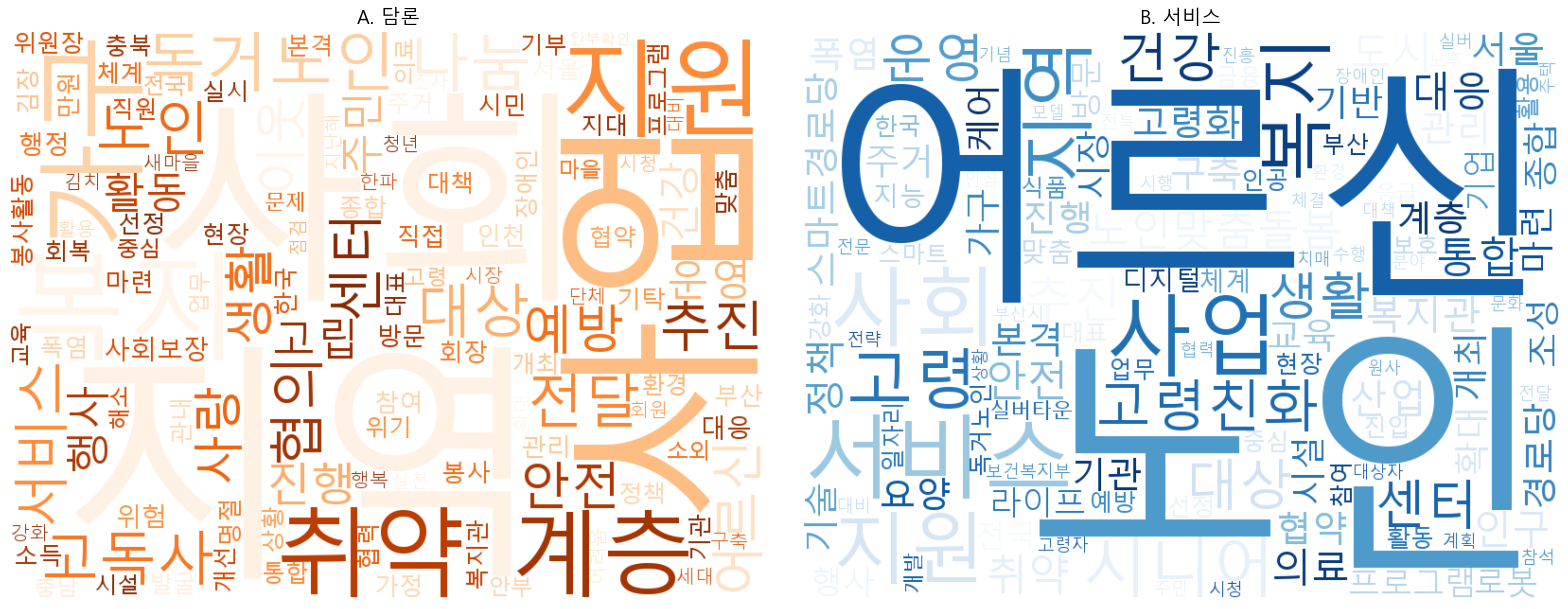

A 상위: ['지역', '사회', '사업', '복지', '가구', '지원', '취약', '계층', '독거노인', '나눔', '전달', '고독사']
B 상위: ['노인', '어르신', '서비스', '사업', '사회', '지원', '복지', '지역', '고령', '시니어', '고령친화', '대상']


In [9]:
from wordcloud import WordCloud
cntA0 = Counter(w for t in dfA["nouns"] for w in t)
cntB0 = Counter(w for t in dfB["nouns"] for w in t)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cnt, ttl, cmap in [(axes[0], cntA0, "A. 담론", "Oranges"),
                           (axes[1], cntB0, "B. 서비스", "Blues")]:
    wc = WordCloud(font_path=FONT_PATH, width=800, height=600, background_color="white",
                   colormap=cmap, max_words=120).generate_from_frequencies(dict(cnt.most_common(120)))
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(ttl, fontsize=14)
plt.tight_layout(); plt.show()
print("A 상위:", [w for w, _ in cntA0.most_common(12)])
print("B 상위:", [w for w, _ in cntB0.most_common(12)])

## 3. 두 담론은 어떤 주제로 이루어져 있나 (토픽 모델)

각 묶음에 잠재 디리클레 할당(LDA) 토픽 모델을 적용해 기사들이 어떤 주제로 나뉘는지 살펴본다. 두 묶음을 같은 사전 위에서 모델링해 토픽끼리 견줄 수 있도록 했다.

In [10]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

nounsA, nounsB = dfA["nouns"].tolist(), dfB["nouns"].tolist()
shared = Dictionary(nounsA + nounsB)   # 두 코퍼스 비교 가능하도록 사전 공유
shared.filter_extremes(no_below=5, no_above=0.5)
corpA = [shared.doc2bow(t) for t in nounsA]
corpB = [shared.doc2bow(t) for t in nounsB]
print("공유 사전 크기:", len(shared))

공유 사전 크기: 5045


### 토픽 개수는 몇 개가 적절한가

두 묶음을 같은 개수의 토픽으로 모델링해야 서로 비교할 수 있다. 토픽 응집도(coherence)는 토픽이 4개일 때와 12개일 때 가장 높았다. 그러나 아래에서 두 후보를 직접 비교해 보면, 12개로 나눌 경우 지명이나 잡음에 가까운 토픽으로 잘게 쪼개져 해석이 어렵다. 반면 4개는 적은 수로도 주제가 또렷이 갈린다. 따라서 응집도가 높으면서 해석도 분명한 **토픽 4개**를 택한다.

k=4: coherence=0.4993


k=6: coherence=0.4703


k=8: coherence=0.4817


k=10: coherence=0.5031


k=12: coherence=0.5071


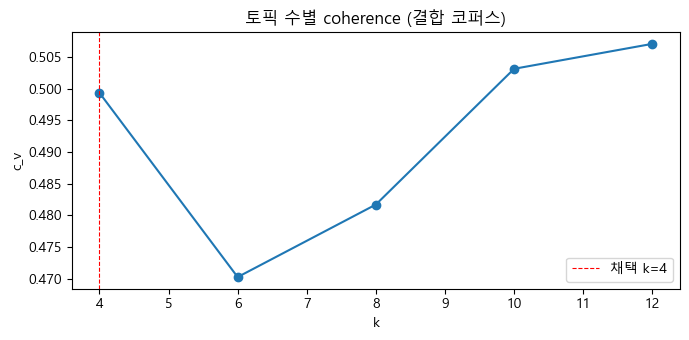

In [11]:
rows = []
allcorp, alltok = corpA + corpB, nounsA + nounsB
for k in range(4, 13, 2):
    m = LdaModel(allcorp, id2word=shared, num_topics=k, passes=5, random_state=42)
    cv = CoherenceModel(model=m, texts=alltok, dictionary=shared, coherence="c_v").get_coherence()
    rows.append((k, cv)); print(f"k={k}: coherence={cv:.4f}")
coh = pd.DataFrame(rows, columns=["k", "coherence"])
plt.figure(figsize=(7, 3.5)); plt.plot(coh["k"], coh["coherence"], "o-")
plt.axvline(4, color="red", ls="--", lw=.8, label="채택 k=4"); plt.legend()
plt.xlabel("k"); plt.ylabel("c_v"); plt.title("토픽 수별 coherence (결합 코퍼스)")
plt.tight_layout(); plt.show()

In [12]:
# coherence 두 봉우리(k=4, k=12) 토픽을 직접 비교 → 어느 쪽이 해석 가능한가
for kk in (4, 12):
    mk = LdaModel(allcorp, id2word=shared, num_topics=kk, passes=10, random_state=42)
    print(f"--- k={kk} 토픽 (결합 코퍼스) ---")
    for t in range(kk):
        print(f"  T{t}: " + ", ".join(w for w, _ in mk.show_topic(t, 8)))
    print()
# k=12는 지명·잡음 토픽으로 과분할되어 해석이 어렵다 → coherence가 지지하고 해석도 쉬운 k=4 채택
K = 4

--- k=4 토픽 (결합 코퍼스) ---
  T0: 폭염, 취약, 안전, 보호, 계층, 대책, 노인, 여름철
  T1: 사회, 노인, 고령, 시니어, 고령친화, 사업, 복지, 정책
  T2: 서비스, 사업, 어르신, 지원, 사회, 협약, 노인맞춤돌봄, 대상
  T3: 지역, 어르신, 노인, 사회, 지원, 복지관, 독거노인, 행사



--- k=12 토픽 (결합 코퍼스) ---
  T0: 폭염, 취약, 보호, 대책, 계층, 안전, 여름철, 대비
  T1: 고령친화, 사업, 도시, 로봇, 의료, 조성, 건강, 노인
  T2: 서비스, 안전, 독거노인, 가구, 응급, 안심, 고독사, 지능
  T3: 협약, 통합, 서비스, 기업, 케어, 의료, 산업, 요양
  T4: 시니어, 시장, 주거, 금융, 서울, 보험, 실버타운, 주택
  T5: 어르신, 사업, 지원, 대상, 사회, 건강, 가구, 프로그램
  T6: 지역, 전달, 독거노인, 나눔, 계층, 센터, 취약, 행사
  T7: 어르신, 서비스, 노인, 노인맞춤돌봄, 교육, 복지관, 생활, 복지
  T8: 복지, 연구, 의회, 의원, 사회, 개최, 정책, 보고
  T9: 아이, 지넷, 급식, 방송, 본사, 대표, 대표이사, 플랫폼
  T10: 인천, 의약품, 노인, 일보, 서울, 장수, 중국, 충북도
  T11: 인구, 고령, 사회, 고령화, 노인, 진입, 정책, 전체



In [13]:
ldaA = LdaModel(corpA, id2word=shared, num_topics=K, passes=15, iterations=100, random_state=42)
ldaB = LdaModel(corpB, id2word=shared, num_topics=K, passes=15, iterations=100, random_state=42)

def topic_words(lda, n=10):
    return {t: [w for w, _ in lda.show_topic(t, n)] for t in range(lda.num_topics)}
print("\n[A. 담론 토픽]")
for t, ws in topic_words(ldaA).items(): print(f"  A{t}: {', '.join(ws)}")
print("\n[B. 서비스 토픽]")
for t, ws in topic_words(ldaB).items(): print(f"  B{t}: {', '.join(ws)}")


[A. 담론 토픽]
  A0: 안전, 폭염, 인천, 취약, 대응, 대책, 계층, 점검, 화재, 노인
  A1: 사회, 노인, 사업, 지역, 지원, 선정, 의료, 서울, 한국, 복지
  A2: 복지, 가구, 사업, 고독사, 사회, 서비스, 지역, 예방, 고립, 위험
  A3: 지역, 나눔, 계층, 취약, 전달, 독거노인, 협의, 사랑, 행사, 이웃

[B. 서비스 토픽]
  B0: 시니어, 로봇, 금융, 고령, 산업, 식품, 서울, 주거, 사회, 시장
  B1: 사업, 고령친화, 사회, 노인, 도시, 복지, 정책, 고령, 지역, 어르신
  B2: 어르신, 노인, 서비스, 취약, 폭염, 지원, 노인맞춤돌봄, 안전, 지역, 대상
  B3: 협약, 라이프, 시니어, 업무, 케어, 서비스, 체결, 센터, 기업, 전문


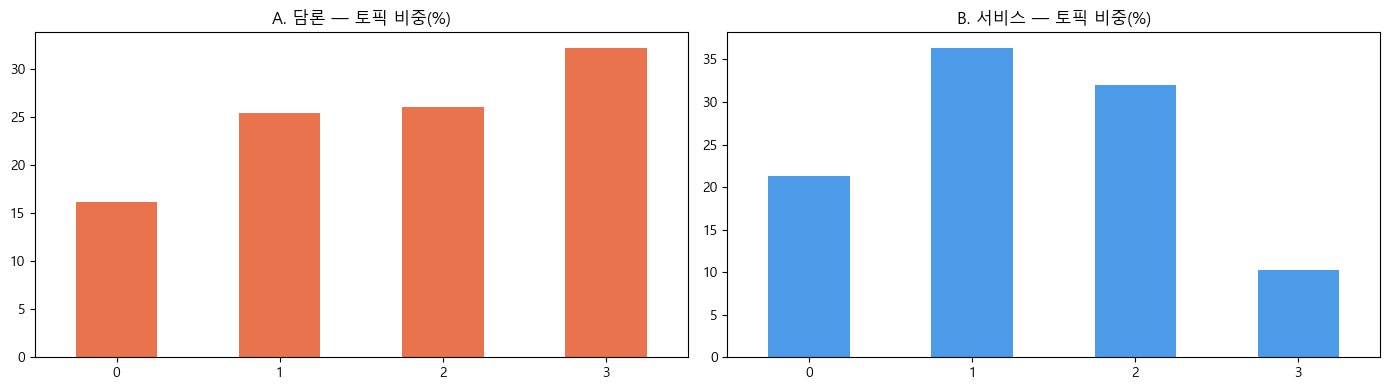

A 토픽 비중(%): {0: 16.2, 1: 25.5, 2: 26.1, 3: 32.3}
B 토픽 비중(%): {0: 21.3, 1: 36.4, 2: 32.0, 3: 10.3}


In [14]:
def dom_dist(lda, corp):
    dom = [max(lda.get_document_topics(b), key=lambda x: x[1])[0] if b else -1 for b in corp]
    return pd.Series(dom).value_counts(normalize=True).sort_index() * 100

distA, distB = dom_dist(ldaA, corpA), dom_dist(ldaB, corpB)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
distA.plot.bar(ax=axes[0], color="#E8734C", title="A. 담론 — 토픽 비중(%)"); axes[0].tick_params(axis="x", rotation=0)
distB.plot.bar(ax=axes[1], color="#4C9BE8", title="B. 서비스 — 토픽 비중(%)"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
print("A 토픽 비중(%):", distA.round(1).to_dict())
print("B 토픽 비중(%):", distB.round(1).to_dict())

## 4. 각 담론에 유독 두드러지는 단어 (log-odds)

단순 빈도는 묶음의 크기에 좌우되므로, 크기 차이를 보정하는 log-odds 비(Monroe 외, 2008)를 사용한다. 이 값이 클수록 그 묶음에서 상대적으로 더 특징적으로 쓰인 단어다.

=== A(담론)에 특징적인 단어 ===
word         z  freq_A  freq_B
  가구 25.243250    1799     520
  나눔 23.917459    1239     215
 고독사 22.642003    1064     151
  협의 21.131085     971     170
독거노인 20.489817    1303     417
  지역 20.285579    2933    1585
  계층 20.047544    1560     606
  이웃 19.673569     807      62
  전달 19.384254    1075     314
  사랑 18.550956     772     148
  고립 18.433234     734     125
사회보장 17.121890     635     109
  봉사 15.482658     503      75
  기탁 14.439571     426      42
  소득 14.165602     521     133

=== B(서비스)에 특징적인 단어 ===
  word          z  freq_A  freq_B
    노인 -26.848292    1056    2796
   어르신 -25.900215     873    2437
   서비스 -24.331862     958    2436
   시니어 -23.855293      82    1232
    고령 -23.210030     265    1279
노인맞춤돌봄 -20.674538      60     932
    도시 -18.920795     191     874
    산업 -18.358166     129     749
    요양 -16.912016      60     595
  고령친화 -16.013063       9    1179
    인구 -15.696689     208     723
    통합 -15.402107     344     920
   경로당 -14.968

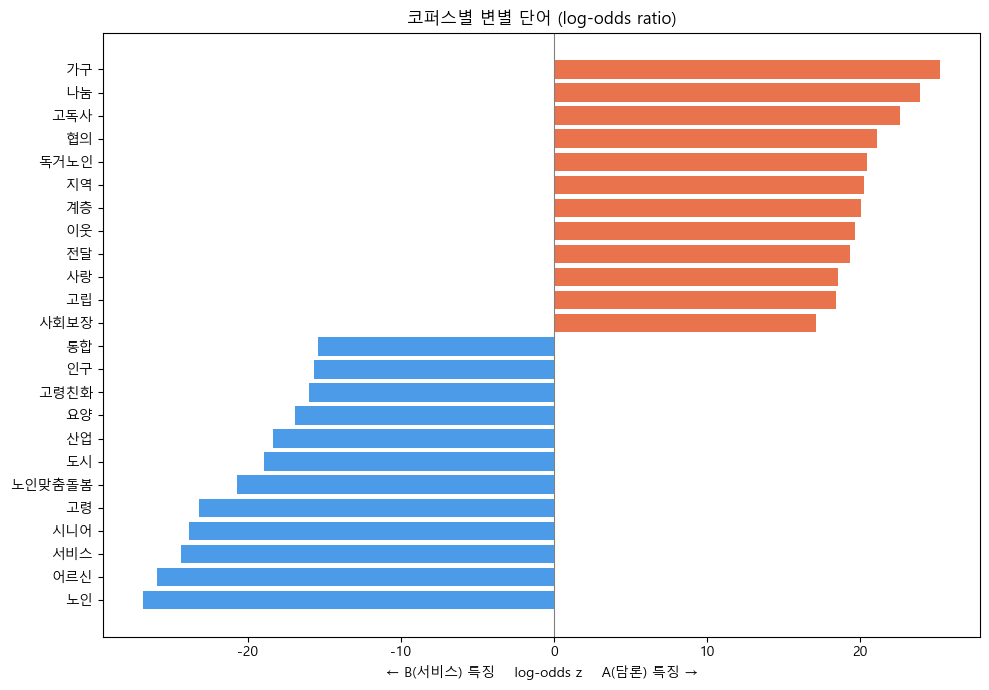

In [15]:
cntA = Counter(w for t in nounsA for w in t)
cntB = Counter(w for t in nounsB for w in t)
lo = log_odds(cntA, cntB, a0=1000.0, min_count=10)

topB = lo.head(15)            # z 최소 = B 특징어
topA = lo.tail(15).iloc[::-1] # z 최대 = A 특징어
print("=== A(담론)에 특징적인 단어 ==="); print(topA[["word", "z", "freq_A", "freq_B"]].to_string(index=False))
print("\n=== B(서비스)에 특징적인 단어 ==="); print(topB[["word", "z", "freq_A", "freq_B"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
both = pd.concat([topA.head(12), topB.head(12)]).sort_values("z")
colors = ["#4C9BE8" if z < 0 else "#E8734C" for z in both["z"]]
ax.barh(both["word"], both["z"], color=colors)
ax.axvline(0, color="gray", lw=.8); ax.set_xlabel("← B(서비스) 특징    log-odds z    A(담론) 특징 →")
ax.set_title("코퍼스별 변별 단어 (log-odds ratio)"); plt.tight_layout(); plt.show()

## 5. 시니어를 어떻게 부르는가 — 이 분석의 핵심

시니어를 가리키는 방식을 두 어휘군으로 나누어 측정한다. 하나는 '지원·보호·돌봄·복지'처럼 시니어를 *수혜·보호의 대상*으로 그리는 어휘이고, 다른 하나는 '이용·구매·제품·서비스·사용자'처럼 *능동적인 주체*로 그리는 어휘다. 기사마다 (주체 어휘 수 − 수혜 어휘 수) ÷ (둘의 합)으로 **주체성 지수**를 구한다. −1에 가까울수록 수혜 대상으로, +1에 가까울수록 능동적 주체로 부른다는 뜻이다.

                      코퍼스  수혜어 출현 문서%  주체어 출현 문서%  주체성지수(평균)
            A 담론(균형 5059)        67.5        34.2     -0.474
              B 서비스(5059)        59.3        64.5      0.062
A 담론(전체 20079·robustness)        67.5        34.4     -0.472


C:\Users\compo\AppData\Local\Temp\ipykernel_9020\1669885764.py:25: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  ax.set_title("시니어 호명 방식의 갭"); plt.tight_layout(); plt.show()
C:\Users\compo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


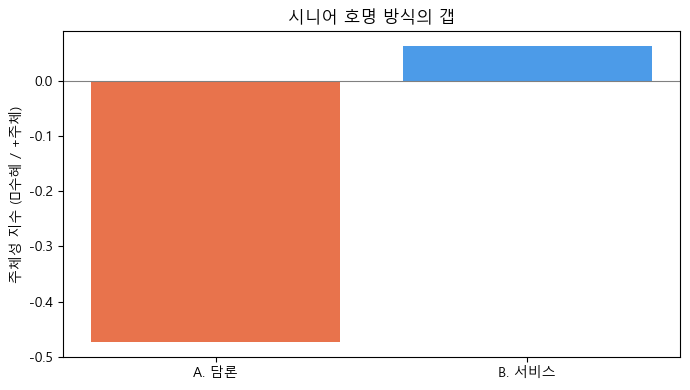

In [16]:
def corpus_framing(nouns_list):
    rows = [framing_index(t) for t in nouns_list]
    fr = pd.DataFrame(rows, columns=["recipient", "active", "idx"])
    return fr

frA = corpus_framing(nounsA); frB = corpus_framing(nounsB)
frA_full = corpus_framing(dfA_full["nouns"].tolist())   # robustness: 전체 A

def summ(fr, name):
    return {
        "코퍼스": name,
        "수혜어 출현 문서%": round((fr["recipient"] > 0).mean() * 100, 1),
        "주체어 출현 문서%": round((fr["active"] > 0).mean() * 100, 1),
        "주체성지수(평균)": round(fr["idx"].mean(), 3),
    }
tab = pd.DataFrame([summ(frA, f"A 담론(균형 {len(frA)})"),
                    summ(frB, f"B 서비스({len(frB)})"),
                    summ(frA_full, f"A 담론(전체 {len(frA_full)}·robustness)")])
print(tab.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
vals = [frA["idx"].mean(), frB["idx"].mean()]
ax.bar(["A. 담론", "B. 서비스"], vals, color=["#E8734C", "#4C9BE8"])
ax.axhline(0, color="gray", lw=.8); ax.set_ylabel("주체성 지수 (−수혜 / +주체)")
ax.set_title("시니어 호명 방식의 갭"); plt.tight_layout(); plt.show()

## 6. 두 담론의 정서는 어떻게 다른가 (감성 분석)

같은 KNU 한국어 감성사전으로 두 묶음의 어조를 비교한다. (크기를 맞춘 5,059건 대 5,059건)

감성사전 단어: 6382
감성 점수화 중... (약 2~3분)


  0%|          | 0/5059 [00:00<?, ?it/s]

  0%|          | 0/5059 [00:00<?, ?it/s]

A 감성%: {'positive': 60.8, 'neutral': 14.8, 'negative': 24.4} | 평균: 1.399
B 감성%: {'positive': 63.2, 'neutral': 20.3, 'negative': 16.5} | 평균: 1.557


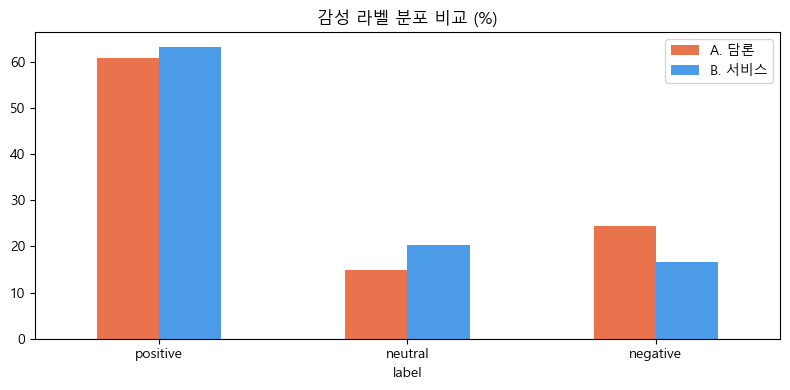

In [17]:
lexicon = load_lexicon(LEXICON_PATH)
print("감성사전 단어:", len(lexicon))
print("감성 점수화 중... (약 2~3분)")
def senti_label_dist(df):
    res = df[BODY].fillna("").progress_apply(lambda t: score_document(t, lexicon))
    sc = pd.DataFrame(res.tolist(), columns=["score", "pos", "neg", "n", "label"])
    return sc

scA, scB = senti_label_dist(dfA), senti_label_dist(dfB)
dfA["senti"] = scA["score"].values; dfB["senti"] = scB["score"].values   # 트렌드용 부착
def sdist(sc):
    d = sc["label"].value_counts(normalize=True).reindex(["positive", "neutral", "negative"]).fillna(0) * 100
    return d.round(1)
print("A 감성%:", sdist(scA).to_dict(), "| 평균:", round(scA["score"].mean(), 3))
print("B 감성%:", sdist(scB).to_dict(), "| 평균:", round(scB["score"].mean(), 3))

comp = pd.DataFrame({"A. 담론": sdist(scA), "B. 서비스": sdist(scB)})
comp.plot.bar(figsize=(8, 4), color=["#E8734C", "#4C9BE8"]); plt.xticks(rotation=0)
plt.title("감성 라벨 분포 비교 (%)"); plt.tight_layout(); plt.show()

## 7. 시간에 따른 변화 (월별 추이)

두 담론의 월별 기사량과 월별 평균 감성이 1년 동안 어떻게 움직였는지 비교한다. 같은 기간을 다루므로 추세를 나란히 견줄 수 있다.

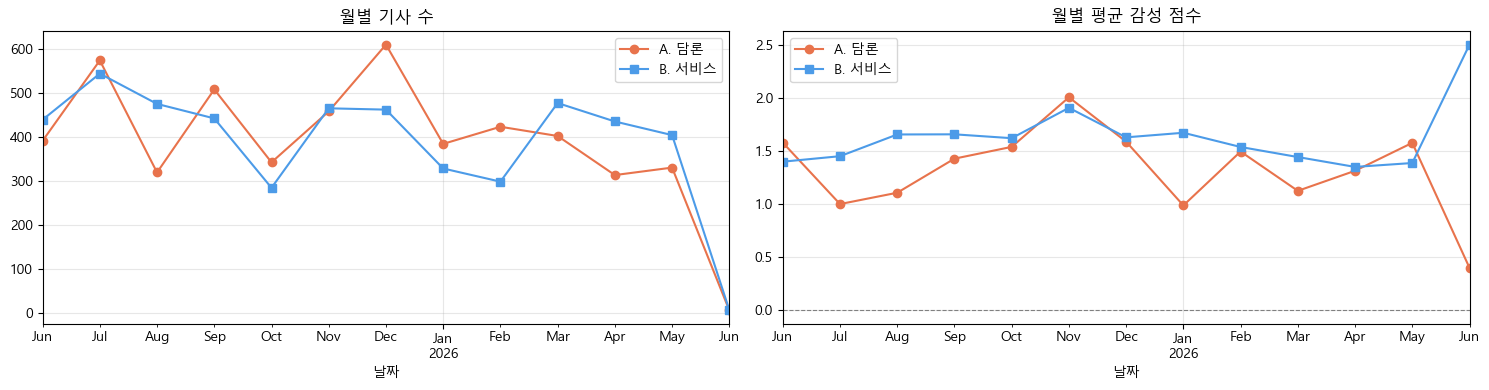

In [18]:
volA = dfA.set_index("날짜").resample("ME").size()
volB = dfB.set_index("날짜").resample("ME").size()
senA = dfA.set_index("날짜").resample("ME")["senti"].mean()
senB = dfB.set_index("날짜").resample("ME")["senti"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
volA.plot(ax=axes[0], marker="o", color="#E8734C", label="A. 담론")
volB.plot(ax=axes[0], marker="s", color="#4C9BE8", label="B. 서비스")
axes[0].set_title("월별 기사 수"); axes[0].legend(); axes[0].grid(alpha=.3)
senA.plot(ax=axes[1], marker="o", color="#E8734C", label="A. 담론")
senB.plot(ax=axes[1], marker="s", color="#4C9BE8", label="B. 서비스")
axes[1].axhline(0, color="gray", ls="--", lw=.8)
axes[1].set_title("월별 평균 감성 점수"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. 두 담론은 얼마나 겹치는가 (토픽 유사도)

코퍼스 A의 토픽과 B의 토픽이 단어 구성 면에서 얼마나 닮았는지 코사인 유사도로 잰다. 값이 높은 칸은 두 담론이 공유하는 주제, 낮은 칸은 한쪽에만 있는 고유한 주제를 뜻한다.

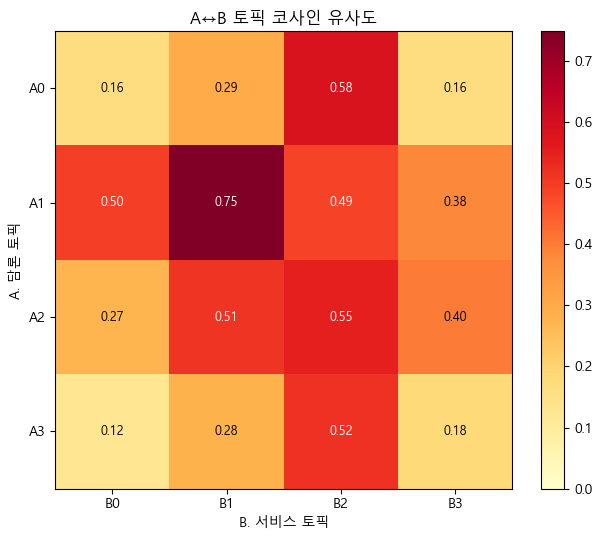

최대 유사도(가장 닮은 A-B 토픽쌍): 0.749
평균 유사도: 0.385


In [19]:
from numpy.linalg import norm
TA, TB = ldaA.get_topics(), ldaB.get_topics()   # (K x vocab)
sim = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        sim[i, j] = TA[i] @ TB[j] / (norm(TA[i]) * norm(TB[j]))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(sim, cmap="YlOrRd", vmin=0, vmax=sim.max())
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels([f"B{j}" for j in range(K)]); ax.set_yticklabels([f"A{i}" for i in range(K)])
ax.set_xlabel("B. 서비스 토픽"); ax.set_ylabel("A. 담론 토픽")
for i in range(K):
    for j in range(K):
        ax.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center",
                color="white" if sim[i,j] > sim.max()*0.6 else "black", fontsize=9)
plt.colorbar(im, fraction=0.046); ax.set_title("A↔B 토픽 코사인 유사도"); plt.tight_layout(); plt.show()
print("최대 유사도(가장 닮은 A-B 토픽쌍):", round(sim.max(), 3))
print("평균 유사도:", round(sim.mean(), 3))

## 9. 단어들의 관계 지도 (동시출현 네트워크)

각 묶음에서 자주 쓰인 단어들이 같은 기사에 함께 등장하는 관계를 그물처럼 그린다. 어떤 단어가 담론의 중심에 자리 잡고 있는지 두 묶음을 비교한다.

A 네트워크: 노드 40 엣지 649
B 네트워크: 노드 40 엣지 621


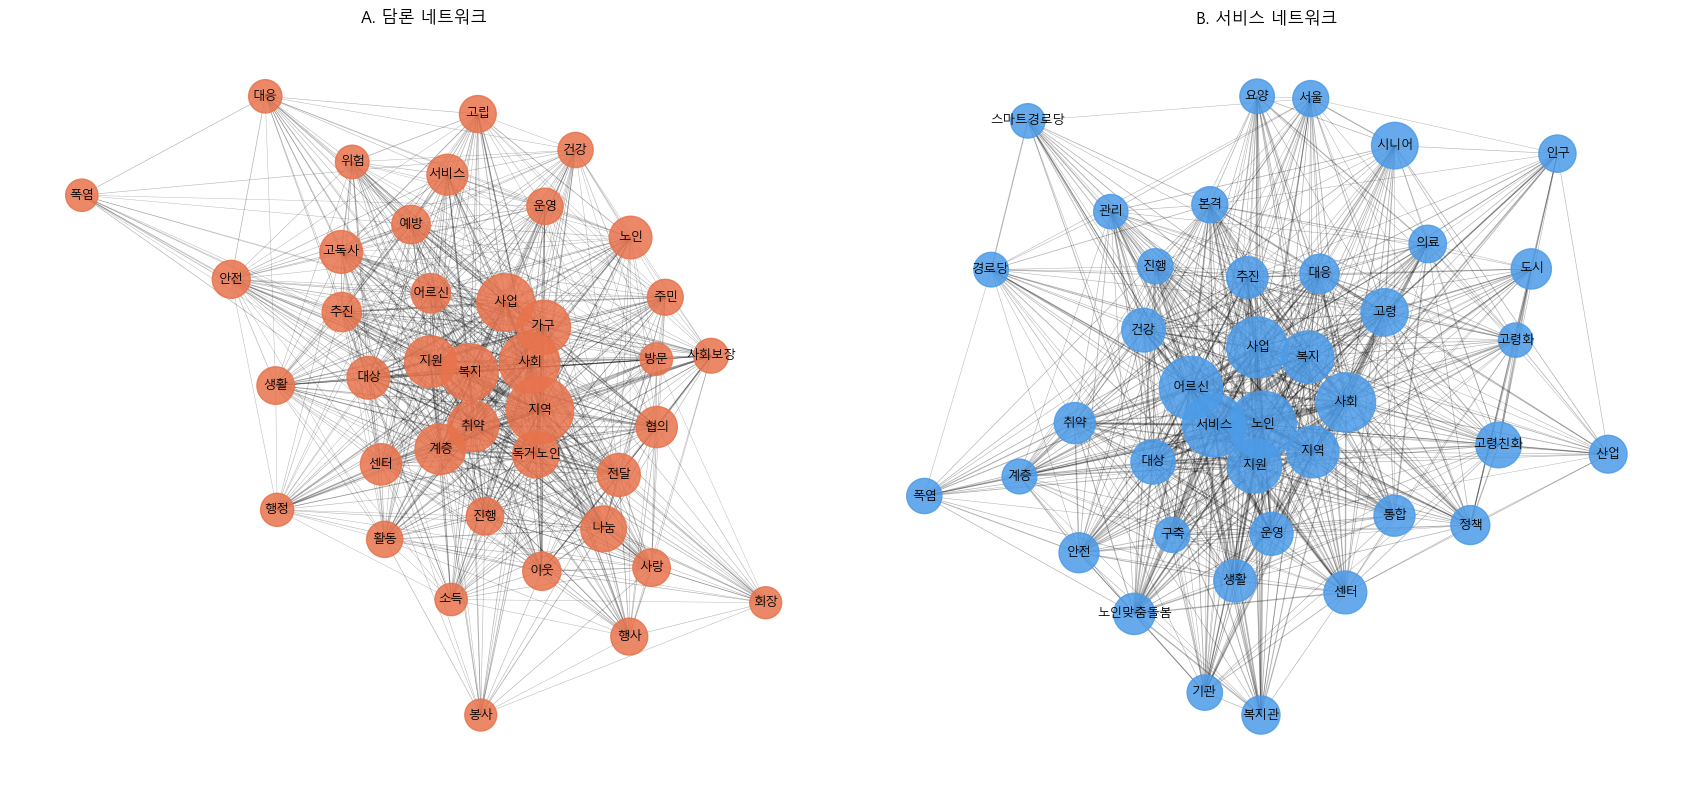

A 중심어: ['지역', '지원', '취약', '계층', '사회', '복지', '가구', '대상']
B 중심어: ['노인', '지원', '지역', '추진', '어르신', '서비스', '사업', '사회']


In [20]:
GA = build_network(nounsA, top_n=40, min_cooc=40)
GB = build_network(nounsB, top_n=40, min_cooc=40)
print("A 네트워크: 노드", GA.number_of_nodes(), "엣지", GA.number_of_edges())
print("B 네트워크: 노드", GB.number_of_nodes(), "엣지", GB.number_of_edges())

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
draw_network(GA, axes[0], "A. 담론 네트워크", "#E8734C")
draw_network(GB, axes[1], "B. 서비스 네트워크", "#4C9BE8")
plt.tight_layout(); plt.show()

import networkx as nx
def top_deg(G, k=8):
    d = nx.degree_centrality(G)
    return [w for w, _ in sorted(d.items(), key=lambda x: -x[1])[:k]]
print("A 중심어:", top_deg(GA))
print("B 중심어:", top_deg(GB))

## 결론 — 같은 시니어, 다른 이름

지금까지의 분석은 한 방향을 가리킨다. **뉴스 담론은 시니어를 '복지의 수혜를 받는 위기의 대상'으로, 서비스 담론은 '서비스를 이용하고 시장을 이루는 능동적 주체'로 부른다.** 같은 인구를 보면서도 부르는 이름이 다른 것이다.

가장 분명한 근거는 **호명 방식**이다. 주체성 지수는 담론 A에서 −0.47, 서비스 B에서 +0.06으로 나타났다. 담론 A는 기사의 67.5%에 '지원·돌봄·복지' 같은 수혜 어휘가 등장한 반면 주체 어휘는 34%에 그쳤고, 서비스 B는 주체 어휘가 64.5%로 균형을 이뤘다. 전체 코퍼스 A(20,079건)로 다시 계산해도 −0.47로 같아, 이 차이가 표본 크기 때문이 아님을 확인했다.

**두드러지는 단어**도 두 세계를 갈라 보여준다. 담론 A의 특징어는 나눔·봉사·고독사·계층·독거노인·사회보장·기탁으로 시혜와 온정, 위기에 닿아 있고, 서비스 B의 특징어는 서비스·시니어·산업·노인맞춤돌봄·고령친화·실버타운·로봇·케어로 서비스와 산업, 시장에 닿아 있다.

**주제 구성**에서도 담론 A는 '나눔·온정'이 32.3%로 가장 크고 '고독사·고립의 위기'가 26.1%로 뒤따라, 시혜와 위기가 절반을 넘는다. 반면 서비스 B는 '고령친화 정책'(36.4%)·'돌봄 서비스'(32.0%)·'실버 산업과 시장'(21.3%)으로 정책과 서비스, 산업이 중심을 이룬다.

**정서** 면에서는 서비스 B(평균 +1.56, 긍정 63%)가 담론 A(+1.40, 긍정 61%)보다 밝고, 부정 기사 비율도 담론 A(24.4%)가 서비스 B(16.5%)보다 높다. 죽음과 고립을 다루는 담론이 그만큼 더 무거운 셈이다.

끝으로 **두 담론의 주제는 대체로 겹치지 않는다**(평균 유사도 0.39). 가장 닮은 주제는 '취약·폭염·안전'(담론 A의 재난안전 ↔ 서비스 B의 돌봄·안전)으로, 재난과 안전이 두 세계의 유일한 접점이다. 단어 네트워크에서도 담론 A의 중심은 취약·계층·복지·가구였던 반면 서비스 B의 중심은 노인·어르신·서비스·사업이었다.

### 함의

복지 담론과 서비스 담론은 같은 고령 인구를 한쪽은 보호받아야 할 대상으로, 다른 쪽은 비용을 지불하는 사용자로 그린다. 이 호명의 간극은 우리 사회가 시니어를 하나의 통합된 시민으로 바라보지 못하고 둘로 나누어 이해하고 있음을 보여준다.

### 분석의 한계

호명 어휘와 감성사전은 미리 정해 둔 단어 목록에 기댄 것이어서 문맥이나 반어를 온전히 담지 못한다. 따라서 절대적인 수치보다 두 담론 사이의 상대적 차이로 읽는 편이 안전하다. 또한 코퍼스 B는 키워드 검색 결과에서 시니어와 관련된 기사만 추려낸 것이다. 다만 분석에 쓴 지표는 모두 비율과 출현율에 기반해 묶음의 크기에 좌우되지 않으며, 전체 코퍼스 A로 다시 확인해 결과가 표본에 흔들리지 않음을 검증했다.